In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded=files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [22]:
df=pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

In [23]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [25]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [26]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [27]:
df = df.drop([
'Row ID',
'Order ID',
'Customer ID',
'Customer Name',
'Product ID',
'Product Name',
'Country'
],axis=1)

In [28]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Order Month"] = df["Order Date"].dt.month
df["Order Year"] = df["Order Date"].dt.year

df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df = df.drop(["Order Date","Ship Date"],axis=1)

In [29]:
df = pd.get_dummies(df, drop_first=True)

In [62]:
new_df = df.drop(['Profit'],axis=1)
profit= df['Profit']

In [63]:
numeric_cols = new_df.select_dtypes(include=['number']).columns

In [64]:
X= new_df[numeric_cols]
y = profit

In [65]:
from sklearn.model_selection import train_test_split


In [66]:
train_X,test_X,train_y,test_y=train_test_split(X,y,test_size=0.2,random_state=42)

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

In [68]:
from sklearn.linear_model import Lasso

In [69]:
model = Lasso(alpha=0.001, max_iter=10000)

In [70]:
model.fit(train_X, train_y)

Lasso(alpha=0.001, max_iter=10000)

In [71]:
print("Training Score :", model.score(train_X, train_y))
print("Testing Score :", model.score(test_X, test_y))

Training Score : 0.434307343342066
Testing Score : -0.725263282200239


In [72]:
pred = model.predict(test_X)

In [73]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("R2 Score :", r2_score(test_y, pred))
print("MAE :", mean_absolute_error(test_y, pred))
print("MSE :", mean_squared_error(test_y, pred))
print("RMSE :", np.sqrt(mean_squared_error(test_y, pred)))

R2 Score : -0.725263282200239
MAE : 69.88873153443794
MSE : 83649.6072124799
RMSE : 289.22241823980363


In [80]:
import pandas as pd

sample_input_data = pd.DataFrame([[42420, 3000, 2, 0.0, 11, 2016, 3]],
                                 columns=['Postal Code', 'Sales', 'Quantity', 'Discount',
                                          'Order Month', 'Order Year', 'Shipping Days'])

scaled_sample_input = scaler.transform(sample_input_data)
predicted_profit = model.predict(scaled_sample_input)[0]
print(f"Predicted Profit: {predicted_profit:.2f}")

Predicted Profit: 794.42


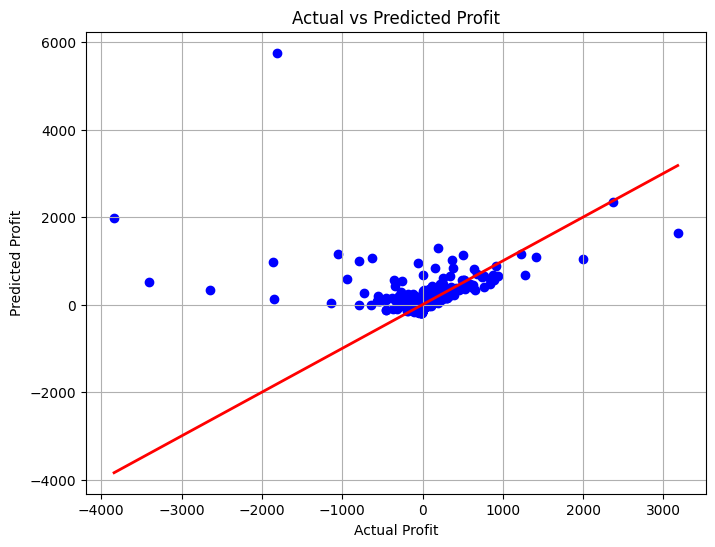

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(test_y, pred, color='blue')

plt.plot([test_y.min(), test_y.max()],
         [test_y.min(), test_y.max()],
         color='red', linewidth=2)

plt.title("Actual vs Predicted Profit")
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")

plt.grid(True)
plt.show()